# Type 2 Fuzzy Time Series — Milk Production
### Huarng & Yu (2005), *Physica A* 353, 445–462
Pure NumPy implementation. Metrics: RMSE, MSE, NMSE, sMAPE.


In [1]:
# ============================================================
# PROCESS IDENTIFICATION
# ============================================================
import os
print(f"Process ID (PID): {os.getpid()}")

Process ID (PID): 9529


In [2]:
# ============================================================
# NOTEBOOK TIMER — START
# ============================================================
import time as _timer_module
_NOTEBOOK_START_TIME = _timer_module.time()
print(f"Notebook execution started at: {_timer_module.strftime('%Y-%m-%d %H:%M:%S')}")

Notebook execution started at: 2026-05-19 23:01:46


In [3]:
# ============================================================
# ALL IMPORTS  (pure NumPy — no sklearn / pandas-fuzzy / statsmodels)
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import csv, math

np.set_printoptions(precision=6, suppress=True)
print(f"NumPy version: {np.__version__}")

# ── Metric helpers ──────────────────────────────────────────
def calc_rmse(actual, predicted):
    """Root Mean Squared Error."""
    return float(np.sqrt(np.mean((np.asarray(actual) - np.asarray(predicted))**2)))

def calc_mse(actual, predicted):
    """Mean Squared Error."""
    return float(np.mean((np.asarray(actual) - np.asarray(predicted))**2))

def calc_nmse(actual, predicted):
    """Normalised MSE  = MSE / ||pred - mean(actual)||^2."""
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    mse = np.mean((a - p)**2)
    denom = np.linalg.norm(p - np.mean(a), 2)**2
    return float(mse / denom) if denom != 0 else float('inf')

def calc_smape(actual, predicted):
    """Symmetric MAPE (%)."""
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    return float(100.0/len(a) * np.sum(2*np.abs(p-a)/(np.abs(a)+np.abs(p)+1e-8)))

NumPy version: 2.4.4


In [4]:
# ============================================================
# 1. Load Time Series Data — Milk Production
# ============================================================
CSV_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                        r"../../content/monthly-milk-production-pounds-p.csv")

dates, values = [], []
with open(CSV_PATH, "r") as f:
    reader = csv.reader(f)
    header = next(reader)
    for row in reader:
        if len(row) < 2: continue
        dates.append(row[0].strip().strip('"'))
        values.append(float(row[1].strip().strip('"')))

data = np.array(values, dtype=np.float64)
print(f"Dataset : Milk Production")
print(f"Shape   : {data.shape}")
print(f"First 5 : {list(zip(dates[:5], data[:5]))}")

Dataset : Milk Production
Shape   : (168,)
First 5 : [('1962-01', np.float64(589.0)), ('1962-02', np.float64(561.0)), ('1962-03', np.float64(640.0)), ('1962-04', np.float64(656.0)), ('1962-05', np.float64(727.0))]


In [5]:
# ============================================================
# 2. Train / Test Split  (83 % / 17 %)
# ============================================================
TRAIN_RATIO = 0.83
split_idx = int(len(data) * TRAIN_RATIO)
train_data = data[:split_idx]
test_data  = data[split_idx:]

print(f"Total : {len(data)}")
print(f"Train : {len(train_data)}  (idx 0..{split_idx-1})")
print(f"Test  : {len(test_data)}  (idx {split_idx}..{len(data)-1})")

Total : 168
Train : 139  (idx 0..138)
Test  : 29  (idx 139..167)


In [6]:
# ============================================================
# 3. Universe of Discourse & Interval Partitioning
#    Implements Step 3-1 of Huarng & Yu (2005), Section 4.
# ============================================================
def compute_universe(train, target_K=57):
    """Compute universe bounds U, interval width w, and count K.
    Implements Step 3-1: adapts w so K stays in ~50-70 range."""
    D_min, D_max = float(np.min(train)), float(np.max(train))
    raw_w = (D_max - D_min) / target_K
    if raw_w == 0: raw_w = 1.0
    mag = 10 ** math.floor(math.log10(raw_w))
    w = round(raw_w / mag) * mag
    if w == 0: w = mag
    U_lo = math.floor(D_min / w) * w - w
    U_hi = math.ceil(D_max / w)  * w + w
    K = int(round((U_hi - U_lo) / w))
    return D_min, D_max, U_lo, U_hi, w, K

D_min, D_max, U_lo, U_hi, w, K = compute_universe(train_data)
midpoints = np.array([U_lo + (k + 0.5) * w for k in range(K)])

print(f"D_min={D_min:.4f}  D_max={D_max:.4f}")
print(f"U=[{U_lo:.4f}, {U_hi:.4f}]  w={w}  K={K}")
print(f"First 5 midpoints: {midpoints[:5]}")
print(f"Last  5 midpoints: {midpoints[-5:]}")

D_min=553.0000  D_max=961.0000
U=[546.0000, 973.0000]  w=7  K=61
First 5 midpoints: [549.5 556.5 563.5 570.5 577.5]
Last  5 midpoints: [941.5 948.5 955.5 962.5 969.5]


In [7]:
# ============================================================
# 4. Fuzzy Set Definition & Fuzzification
#    Step 3-2 (triangular MFs) and Step 3-3 / Definition 4.
# ============================================================
def triangular_membership(x, k, midpoints, w):
    """Membership of x in fuzzy set A_k.  Step 3-2.
    mu=1.0 at midpoint, 0.5 at adjacent midpoints, 0 elsewhere."""
    dist = abs(x - midpoints[k])
    if dist >= 2.0 * w: return 0.0
    elif dist <= w:     return 1.0 - 0.5 * (dist / w)
    else:               return 0.5 * (2.0 * w - dist) / w

def fuzzify(x, midpoints):
    """Assign x to A_k with maximal membership (Definition 4)."""
    return int(np.argmin(np.abs(midpoints - x)))

def fuzzify_series(series, midpoints):
    return np.array([fuzzify(x, midpoints) for x in series])

# Test on 3 samples
samples = [train_data[0], train_data[len(train_data)//2], train_data[-1]]
print("Sample fuzzification:")
for val in samples:
    k = fuzzify(val, midpoints)
    mbs = {j: round(triangular_membership(val, j, midpoints, w), 4)
           for j in range(max(0,k-2), min(K,k+3))}
    print(f"  x={val:.4f} -> A_{k} (mid={midpoints[k]:.4f})  mu={mbs}")

Sample fuzzification:
  x=589.0000 -> A_6 (mid=591.5000)  mu={4: np.float64(0.1786), 5: np.float64(0.6786), 6: np.float64(0.8214), 7: np.float64(0.3214), 8: 0.0}
  x=687.0000 -> A_20 (mid=689.5000)  mu={18: np.float64(0.1786), 19: np.float64(0.6786), 20: np.float64(0.8214), 21: np.float64(0.3214), 22: 0.0}
  x=881.0000 -> A_47 (mid=878.5000)  mu={45: 0.0, 46: np.float64(0.3214), 47: np.float64(0.8214), 48: np.float64(0.6786), 49: np.float64(0.1786)}


In [8]:
# ============================================================
# 5. FLR & FLRG Construction (Type 1 — Chen's model)
#    Definitions 3 & 5 of Huarng & Yu (2005).
# ============================================================
def build_flr(fuzzified):
    """Build FLRs: A_{f[t-1]} -> A_{f[t]}.  Definition 3."""
    return [(fuzzified[t-1], fuzzified[t]) for t in range(1, len(fuzzified))]

def build_flrg(flrs, K):
    """Group FLRs into FLRGs.  Definition 5 / Chen's model."""
    flrg = {k: set() for k in range(K)}
    for lhs, rhs in flrs:
        flrg[lhs].add(rhs)
    return flrg

fuzzified_train = fuzzify_series(train_data, midpoints)
flrs = build_flr(fuzzified_train)
flrg = build_flrg(flrs, K)

print("Sample FLRGs (first 5 non-empty):")
cnt = 0
for k in sorted(flrg):
    if flrg[k]:
        print(f"  A_{k} -> {{ {', '.join(f'A_{j}' for j in sorted(flrg[k]))} }}")
        cnt += 1
        if cnt >= 5: break
print(f"Non-empty FLRGs: {sum(1 for v in flrg.values() if v)} / {K}")

Sample FLRGs (first 5 non-empty):
  A_0 -> { A_5 }
  A_2 -> { A_7, A_13, A_15 }
  A_3 -> { A_4 }
  A_4 -> { A_0 }
  A_5 -> { A_2, A_5, A_7 }
Non-empty FLRGs: 53 / 61


In [9]:
# ============================================================
# 6. Type 2 Observations  (Step 4 of the algorithm)
#    Synthetic high/low = x ± rolling_std(window=5), backward only.
# ============================================================
def rolling_std(series, window=5):
    """Backward-looking rolling std (no look-ahead)."""
    stds = np.empty(len(series))
    for t in range(len(series)):
        stds[t] = np.std(series[max(0,t-window+1):t+1], ddof=0)
    return stds

full_std    = rolling_std(data, window=5)
obs_high    = data + full_std
obs_low     = data - full_std
fuzz_all    = fuzzify_series(data, midpoints)
fuzz_high   = fuzzify_series(obs_high, midpoints)
fuzz_low    = fuzzify_series(obs_low, midpoints)

print("Type 2 obs (first 5):")
print(f"  {'t':>3s} {'x':>10s} {'high':>10s} {'low':>10s} {'A_x':>4s} {'A_hi':>5s} {'A_lo':>5s}")
for t in range(5):
    print(f"  {t:3d} {data[t]:10.4f} {obs_high[t]:10.4f} {obs_low[t]:10.4f}"
          f" {fuzz_all[t]:4d} {fuzz_high[t]:5d} {fuzz_low[t]:5d}")

Type 2 obs (first 5):
    t          x       high        low  A_x  A_hi  A_lo
    0   589.0000   589.0000   589.0000    6     6     6
    1   561.0000   575.0000   547.0000    2     4     0
    2   640.0000   672.7041   607.2959   13    18     8
    3   656.0000   694.2394   617.7606   15    21    10
    4   727.0000   784.4825   669.5175   25    34    17


In [10]:
# ============================================================
# 7. Operators: Union (∨_m) and Intersection (∧_m)
#    Definitions 7-9, Theorems 2-3 of Huarng & Yu (2005).
# ============================================================
def union_m(lhs_indices, flrg, type1_lhs):
    """∨_m operator (Def 8 / Thm 2, Eq 5).  Fallback: Def 9a."""
    result = set()
    for idx in lhs_indices:
        result |= flrg.get(idx, set())
    if not result:
        result = flrg.get(type1_lhs, set())
    if not result:
        result = {type1_lhs}
    return result

def intersection_m(lhs_indices, flrg, type1_lhs):
    """∧_m operator (Def 8 / Thm 2, Eq 6).  Fallback: Def 9b."""
    non_empty = [flrg.get(idx, set()) for idx in lhs_indices]
    non_empty = [s for s in non_empty if s]
    if not non_empty:
        return {type1_lhs}
    result = non_empty[0]
    for s in non_empty[1:]:
        result = result & s
    if not result:
        result = {type1_lhs}
    return result

# Worked example
t_ex = split_idx
l1  = int(fuzz_all[t_ex-1])
lhi = int(fuzz_high[t_ex-1])
llo = int(fuzz_low[t_ex-1])
u_r = union_m([l1, lhi, llo], flrg, l1)
i_r = intersection_m([l1, lhi, llo], flrg, l1)
print(f"Worked example t={t_ex}:")
print(f"  LHS: T1=A_{l1}, Hi=A_{lhi}, Lo=A_{llo}")
print(f"  ∨_m = {{ {', '.join(f'A_{j}' for j in sorted(u_r))} }}")
print(f"  ∧_m = {{ {', '.join(f'A_{j}' for j in sorted(i_r))} }}")

Worked example t=139:
  LHS: T1=A_47, Hi=A_51, Lo=A_43
  ∨_m = { A_56 }
  ∧_m = { A_56 }


In [11]:
# ============================================================
# 8. Forecasting Loop  (all 4 variants)
#    Defuzzification: Section 3.3 — mean of midpoints.
# ============================================================
def defuzzify(fset, midpoints):
    """Defuzzify forecast set -> arithmetic mean of midpoints (Sec 3.3)."""
    if not fset: return np.nan
    return float(np.mean([midpoints[j] for j in sorted(fset)]))

actuals, pred_t1, pred_int, pred_uni, pred_t2 = [], [], [], [], []

for t in range(split_idx, len(data)):
    actuals.append(data[t])
    l1  = int(fuzz_all[t-1])
    lhi = int(fuzz_high[t-1])
    llo = int(fuzz_low[t-1])

    # Type 1 (Chen baseline)
    rhs1 = flrg.get(l1, set()) or {l1}
    f1 = defuzzify(rhs1, midpoints)

    # Intersection
    i_s = intersection_m([l1, lhi, llo], flrg, l1)
    fi = defuzzify(i_s, midpoints)

    # Union
    u_s = union_m([l1, lhi, llo], flrg, l1)
    fu = defuzzify(u_s, midpoints)

    # Type 2
    f2 = (fi + fu) / 2.0

    pred_t1.append(f1); pred_int.append(fi)
    pred_uni.append(fu); pred_t2.append(f2)

actuals    = np.array(actuals)
pred_t1    = np.array(pred_t1)
pred_int   = np.array(pred_int)
pred_uni   = np.array(pred_uni)
pred_t2    = np.array(pred_t2)
print(f"Forecasting done: {len(actuals)} test steps")

Forecasting done: 29 test steps


In [12]:
# ============================================================
# 9. Results — RMSE, MSE, NMSE, sMAPE  (matches Fuzzy_LSTM_SNP format)
# ============================================================
variants = {
    "Type 1 (Chen)":       pred_t1,
    "Intersection (∧_m)":  pred_int,
    "Union (∨_m)":         pred_uni,
    "Type 2 (average)":    pred_t2,
}

all_rmse, all_mse, all_nmse, all_smape = {}, {}, {}, {}
print("=" * 72)
print(f"{'Model':<22s} {'RMSE':>12s} {'MSE':>14s} {'NMSE':>14s} {'sMAPE':>10s}")
print("-" * 72)
for name, preds in variants.items():
    r  = calc_rmse(actuals, preds)
    m  = calc_mse(actuals, preds)
    n  = calc_nmse(actuals, preds)
    s  = calc_smape(actuals, preds)
    all_rmse[name]=r; all_mse[name]=m; all_nmse[name]=n; all_smape[name]=s
    print(f"{name:<22s} {r:12.6f} {m:14.6f} {n:14.10f} {s:10.6f}")
print("=" * 72)

# Summary matching Fuzzy_LSTM_SNP output format
best = min(variants, key=lambda k: all_rmse[k])
print(f"\nBest variant: {best}")
print(f"  RMSE:  {all_rmse[best]:.6f}")
print(f"  MSE:   {all_mse[best]:.6f}")
print(f"  NMSE:  {all_nmse[best]:.10f}")
print(f"  sMAPE: {all_smape[best]:.6f}")

Model                          RMSE            MSE           NMSE      sMAPE
------------------------------------------------------------------------
Type 1 (Chen)             46.902659    2199.859435   0.0177365891   4.327043
Intersection (∧_m)        53.891494    2904.293103   0.0231815006   4.870270
Union (∨_m)               53.168109    2826.847776   0.0198751214   4.819927
Type 2 (average)          51.785658    2681.754353   0.0208815398   4.538801

Best variant: Type 1 (Chen)
  RMSE:  46.902659
  MSE:   2199.859435
  NMSE:  0.0177365891
  sMAPE: 4.327043


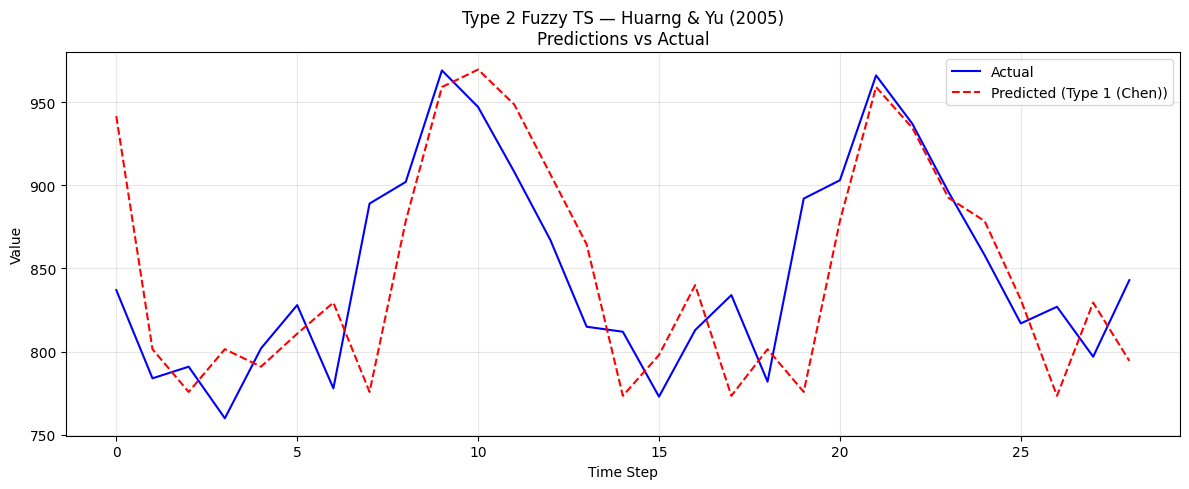

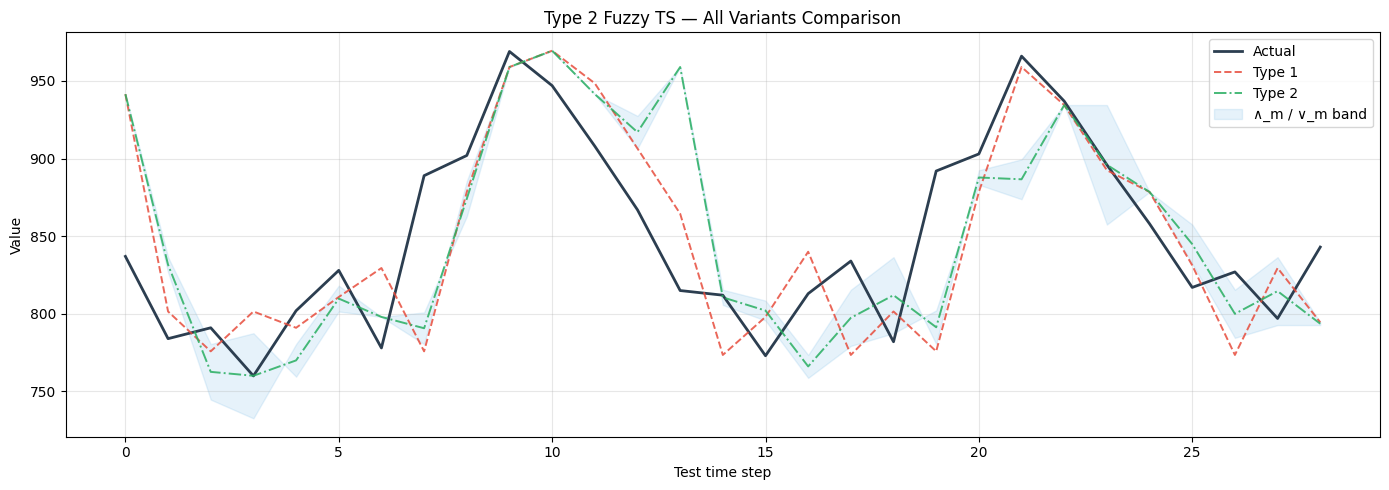

In [13]:
# ============================================================
# 10. Predictions vs Actual (Best Variant)
# ============================================================
best_preds = variants[best]

plt.figure(figsize=(12, 5))
plt.plot(actuals, label='Actual', color='blue', linewidth=1.5)
plt.plot(best_preds, label=f'Predicted ({best})', color='red',
         linewidth=1.5, linestyle='--')
plt.title(f'Type 2 Fuzzy TS — Huarng & Yu (2005)\nPredictions vs Actual')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# All 4 Variants Comparison
# ============================================================
fig, ax = plt.subplots(figsize=(14, 5))
t_axis = np.arange(len(actuals))
ax.plot(t_axis, actuals,  lw=2.0, label="Actual",  color="#2c3e50")
ax.plot(t_axis, pred_t1,  lw=1.4, label="Type 1",  color="#e74c3c", ls="--", alpha=0.85)
ax.plot(t_axis, pred_t2,  lw=1.4, label="Type 2",  color="#27ae60", ls="-.", alpha=0.85)
ax.fill_between(t_axis, pred_int, pred_uni,
                alpha=0.12, color="#3498db", label="∧_m / ∨_m band")
ax.set_xlabel("Test time step"); ax.set_ylabel("Value")
ax.set_title("Type 2 Fuzzy TS — All Variants Comparison")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# NOTEBOOK TIMER — END
# ============================================================
import time as _timer_module
_NOTEBOOK_END_TIME = _timer_module.time()
_NOTEBOOK_ELAPSED = _NOTEBOOK_END_TIME - _NOTEBOOK_START_TIME
_hours, _rem = divmod(_NOTEBOOK_ELAPSED, 3600)
_minutes, _seconds = divmod(_rem, 60)
print(f"\nTotal notebook execution time: {int(_hours)}h {int(_minutes)}m {_seconds:.2f}s")
print(f"Total seconds: {_NOTEBOOK_ELAPSED:.2f}")


Total notebook execution time: 0h 0m 0.71s
Total seconds: 0.71
